In [2]:
import numpy as np
import matplotlib.pyplot as  plt

In [102]:
#创建显示点源数据坐标,下面是我的基本思路
c_10 = np.arange(0,11,1) / 10

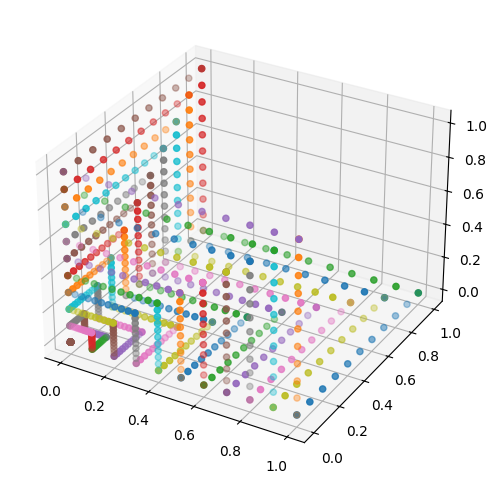

In [114]:
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(projection = '3d')

for r in c_10:
    r_g_b = np.linspace(0,r,11)
    ax.scatter(r,r_g_b,0)
    ax.scatter(r,0,r_g_b)

for g in c_10:
    r_g_b = np.linspace(0,g,11)
    ax.scatter(r_g_b,g,0)
    ax.scatter(0,g,r_g_b)

for b in c_10:
    r_g_b = np.linspace(0,b,11)
    ax.scatter(r_g_b,0,b)
    ax.scatter(0,r_g_b,b)

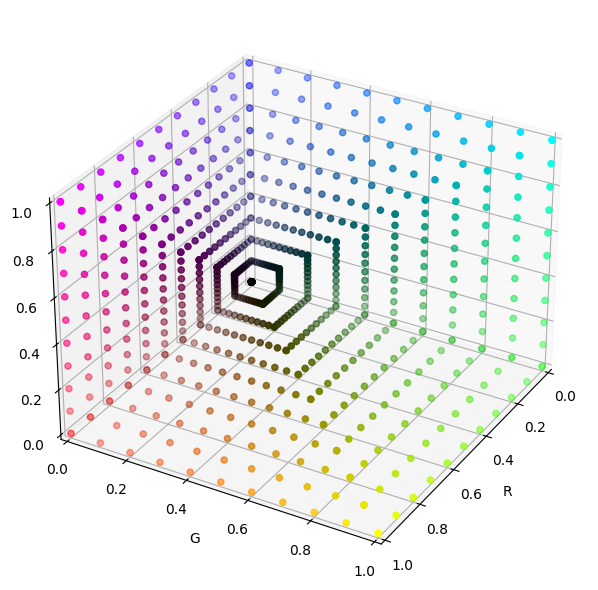

In [133]:
#根据gpt完善了颜色和视角
import numpy as np
import matplotlib.pyplot as plt

c_10 = np.arange(0,11)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(projection = '3d')

#循环通道 R = 0 G = 1 B = 2
for const_axis in range(3):
    #这里进行取模运算 %3是返回3的余数 根据输入的0,1,2数列对应得到 1,2  2,0  0,1 用于对应其他通道
    grad_axes = [(const_axis + 1)%3,(const_axis+2)%3]
    for base in c_10:
        b = base / 10 #归一化得到某颜色轴上的一个确定显示值
        coords = np.linspace(0,b,11) #根据确定显示值延伸另外两个轴的显示值

        for ga in grad_axes: #常量通道为b 渐变通道为coords 剩下一个通道保持0
            pts = np.zeros((11,3)) #配置形状为[11,3]的全零数组
            pts[:,const_axis] = b #常量通道填写
            pts[:,ga] = coords  #渐变通道填写

            ax.scatter(pts[:,0],pts[:,1],pts[:,2],
                       c = pts, #因为前面的归一化,直接使用颜色进行映射
                       s = 20)
#摄像机镜头对准原点,然后原点和摄像机位置连成线 角度调整为此连线相较于原点
#需要注意默认视角不是 0,0度,角度不是按照默认角度进行旋转 而是 0,0 开始旋转
ax.view_init(elev = 30,azim = 30)
ax.set_xlim(0,1);ax.set_ylim(0,1);ax.set_zlim(0,1)
ax.set_xlabel('R');ax.set_ylabel('G');ax.set_zlabel('B')

plt.tight_layout() #布局调整函数
plt.show()

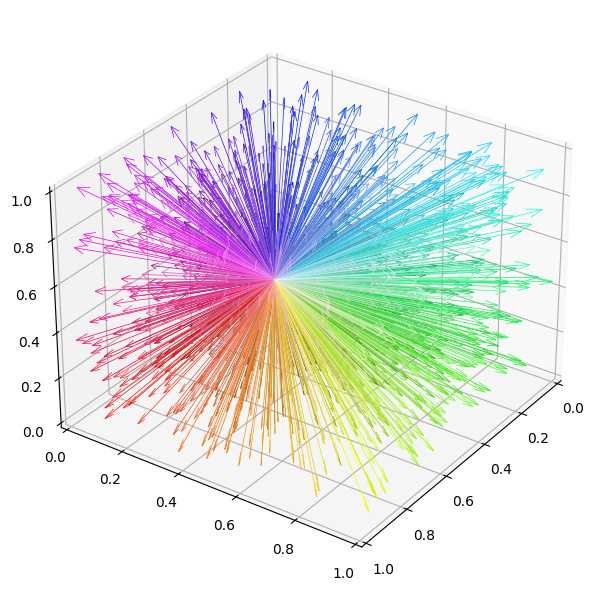

In [211]:
import numpy as np
import matplotlib.pyplot as plt

c_rgbs = np.random.rand(1500,3)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(projection = '3d')

for rgb in c_rgbs:
    ax.quiver(0,0,0,
             *rgb,
             color = rgb,
             arrow_length_ratio = 0.05,
             lw = 0.5)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.view_init(elev = 30,azim = 35)

plt.tight_layout()
plt.show()